In [44]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df=pd.read_csv('wine_data (1).csv',header=None,usecols=[0,1,2,3])
df.columns=['Class label', 'Alcohol', 'Malic acid','Water']

In [46]:
df.shape

(178, 4)

In [48]:
df.sample(5)

,Class label,Alcohol,Malic acid,Water
54,1,13.74,1.67,2.25
36,1,13.28,1.64,2.84
67,2,12.37,1.17,1.92
145,3,13.16,3.57,2.15
45,1,14.21,4.04,2.44


In [49]:
df

,Class label,Alcohol,Malic acid,Water
0,1,14.23,1.71,2.43
1,1,13.20,1.78,2.14
2,1,13.16,2.36,2.67
3,1,14.37,1.95,2.50
4,1,13.24,2.59,2.87
...,...,...,...,...
173,3,13.71,5.65,2.45
174,3,13.40,3.91,2.48
175,3,13.27,4.28,2.26
176,3,13.17,2.59,2.37


<Axes: xlabel='Alcohol', ylabel='Density'>

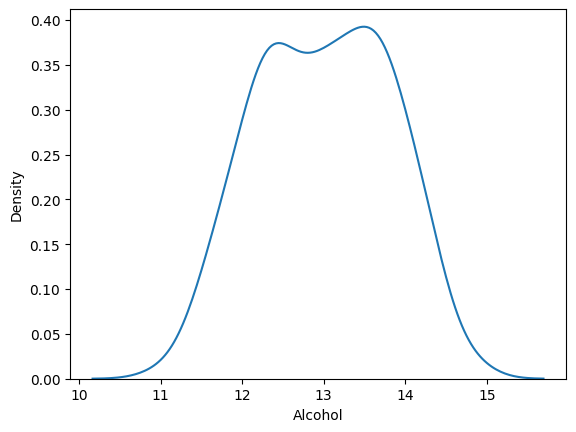

In [50]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

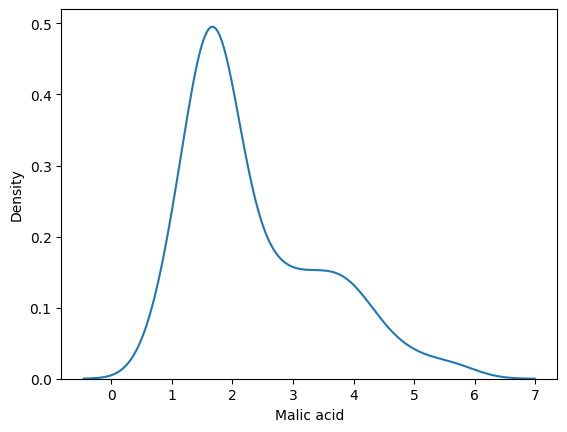

In [52]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Water', ylabel='Density'>

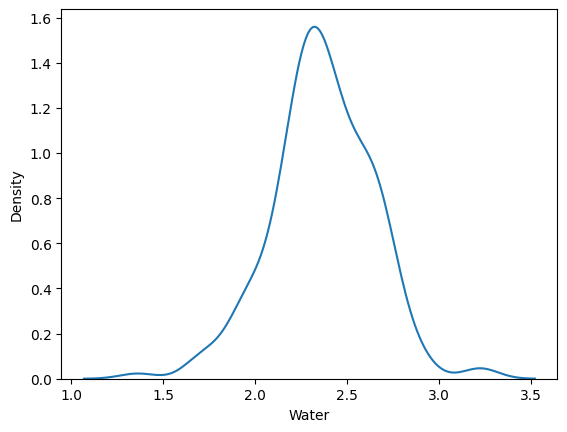

In [53]:
sns.kdeplot(df['Water'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

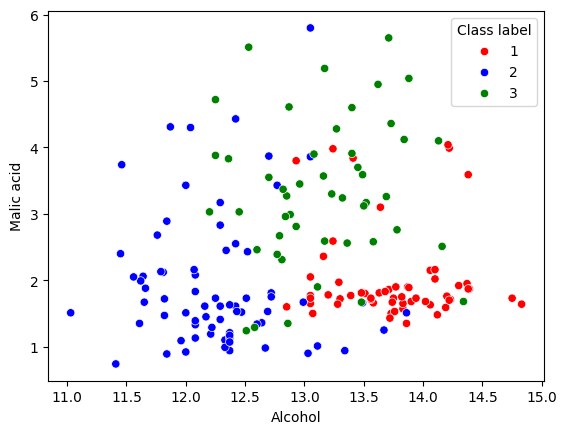

In [54]:
color_dict = {
    1: 'red',
    2: 'blue',
    3: 'green'
}

sns.scatterplot(
    x=df['Alcohol'],
    y=df['Malic acid'],
    
    hue=df['Class label'],
    palette=color_dict
)

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 3), (54, 3))

In [55]:
X_train

,Alcohol,Malic acid,Water
22,13.71,1.86,2.36
108,12.22,1.29,1.94
175,13.27,4.28,2.26
145,13.16,3.57,2.15
71,13.86,1.51,2.67
...,...,...,...
103,11.82,1.72,1.88
67,12.37,1.17,1.92
117,12.42,1.61,2.19
47,13.90,1.68,2.12


In [56]:
y_test

54     1
151    3
63     2
55     1
123    2
121    2
7      1
160    3
106    2
90     2
141    3
146    3
5      1
98     2
168    3
80     2
33     1
18     1
61     2
51     1
66     2
37     1
4      1
104    2
60     2
111    2
126    2
86     2
112    2
164    3
26     1
56     1
129    2
45     1
8      1
44     1
161    3
92     2
94     2
174    3
24     1
30     1
93     2
101    2
113    2
19     1
135    3
74     2
144    3
16     1
131    3
138    3
40     1
158    3
Name: Class label, dtype: int64

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)


,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](3,)","[14.75, 5.65, 3.22]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](3,)","[11.03, 0.89, 1.36]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](3,)","[3.72,4.76,1.86]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Alcohol','Malic acid','Water']"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](3,)","[-2.97,-0.19,-0.73]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,124


In [57]:
# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
X_test_scaled

array([[ 0.72849462,  0.16386555,  0.47849462],
       [ 0.47311828,  0.37394958,  0.60215054],
       [ 0.36021505,  0.05042017,  0.43010753],
       [ 0.68010753,  0.17647059,  0.59139785],
       [ 0.54301075,  1.03151261,  0.41397849],
       [ 0.14247312,  0.24369748,  1.00537634],
       [ 0.81451613,  0.26470588,  0.67204301],
       [ 0.35752688,  0.61764706,  0.5483871 ],
       [ 0.32795699,  0.17647059,  0.40860215],
       [ 0.28225806,  0.19747899,  0.51612903],
       [ 0.62634409,  0.35084034,  0.53225806],
       [ 0.76612903,  0.87184874,  0.46774194],
       [ 0.85215054,  0.18277311,  0.58602151],
       [ 0.36021505,  0.03781513,  0.39784946],
       [ 0.68548387,  0.35504202,  0.71505376],
       [ 0.26075269,  0.00630252,  0.34408602],
       [ 0.73387097,  0.13445378,  0.72043011],
       [ 0.84946237,  0.14705882,  0.60215054],
       [ 0.4327957 ,  0.0987395 ,  0.35483871],
       [ 0.75268817,  0.15966387,  0.66666667],
       [ 0.55913978,  0.02521008,  0.182

In [59]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [60]:
X_train_scaled

,Alcohol,Malic acid,Water
0,0.720430,0.203782,0.537634
1,0.319892,0.084034,0.311828
2,0.602151,0.712185,0.483871
3,0.572581,0.563025,0.424731
4,0.760753,0.130252,0.704301
...,...,...,...
119,0.212366,0.174370,0.279570
120,0.360215,0.058824,0.301075
121,0.373656,0.151261,0.446237
122,0.771505,0.165966,0.408602


In [34]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid,Water
count,124.0,124.0,124.0
mean,13.0,2.4,2.4
std,0.8,1.1,0.3
min,11.0,0.9,1.4
25%,12.4,1.6,2.2
50%,13.0,1.9,2.4
75%,13.6,3.2,2.6
max,14.8,5.6,3.2


In [35]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid,Water
count,124.0,124.0,124.0
mean,0.5,0.3,0.5
std,0.2,0.2,0.1
min,0.0,0.0,0.0
25%,0.4,0.2,0.5
50%,0.5,0.2,0.5
75%,0.7,0.5,0.6
max,1.0,1.0,1.0


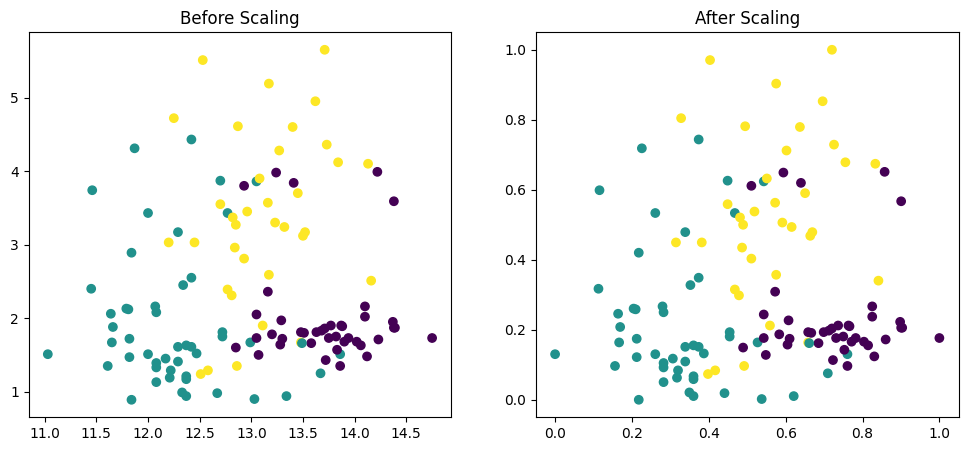

In [40]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c= y_train)
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic acid'],c=y_train)
ax2.set_title('After Scaling')
plt.show()

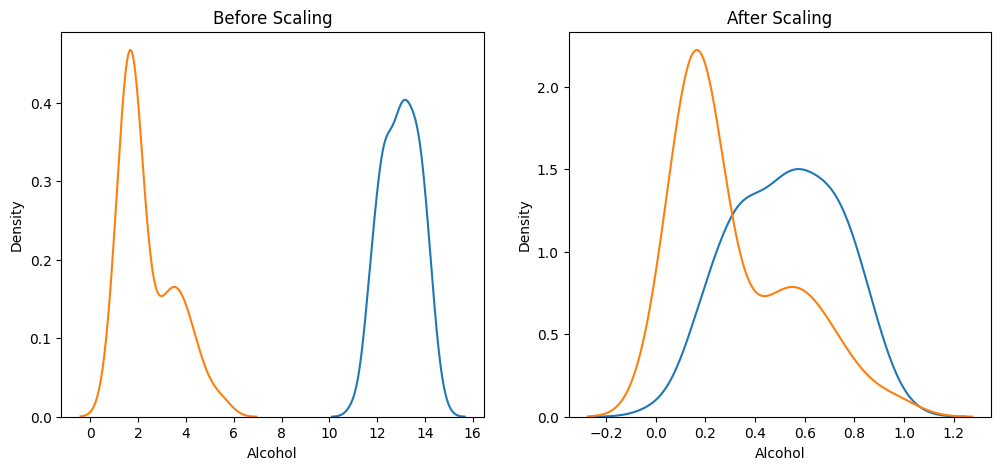

In [61]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)


# after scaling
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

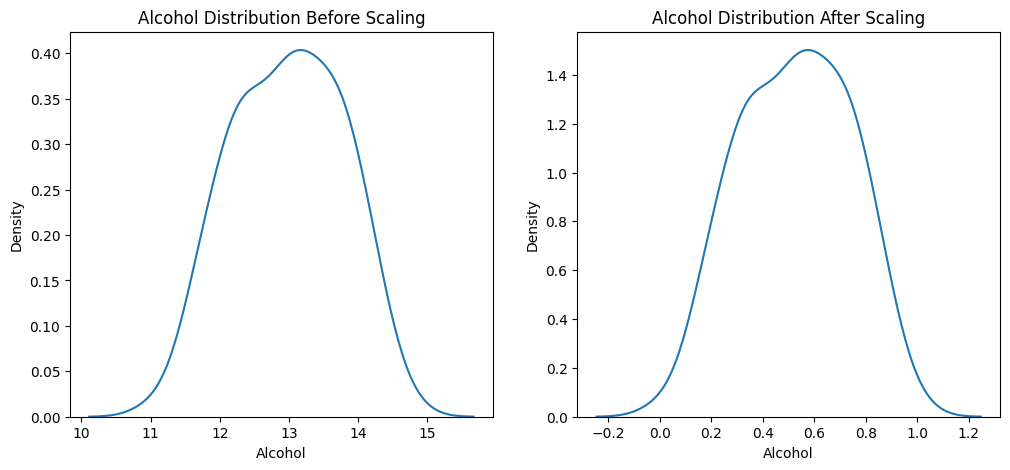

In [62]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

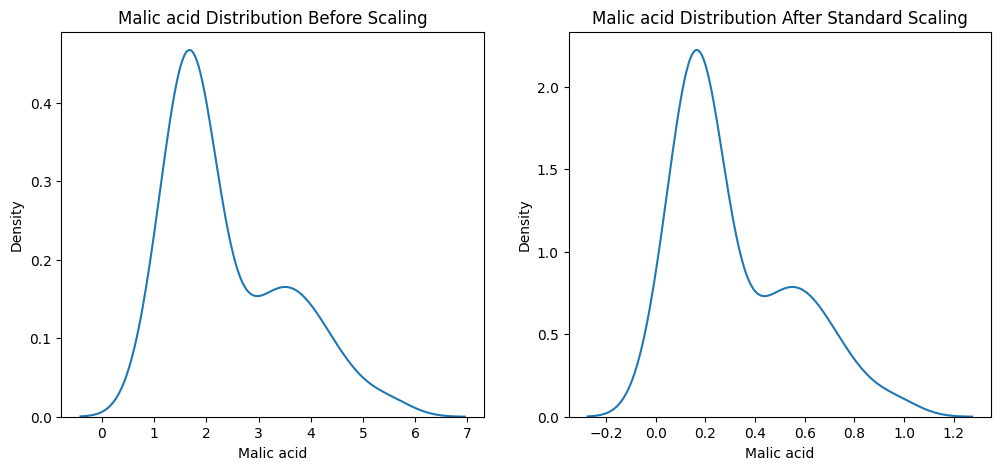

In [43]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()